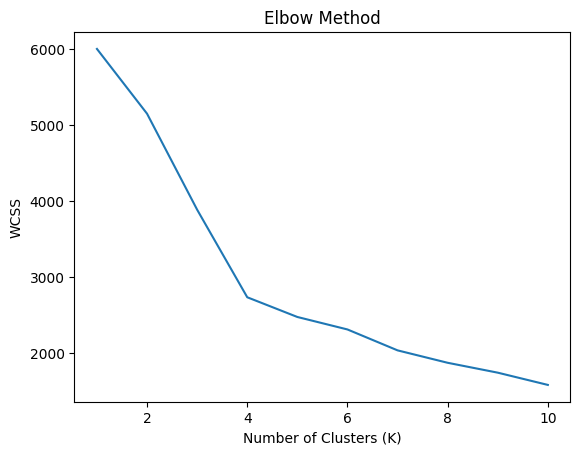

Silhouette Scores:

K = 2, Silhouette Score = 0.1546
K = 3, Silhouette Score = 0.2480
K = 4, Silhouette Score = 0.3295
K = 5, Silhouette Score = 0.2938
K = 6, Silhouette Score = 0.2921
K = 7, Silhouette Score = 0.2616
K = 8, Silhouette Score = 0.2624
K = 9, Silhouette Score = 0.2732
K = 10, Silhouette Score = 0.2743

Cluster Distribution:
Cluster
3    342
0    321
2    170
1    167
Name: count, dtype: int64


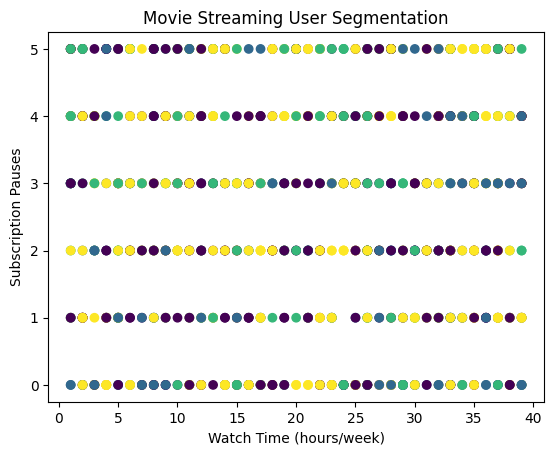

In [1]:
# 🎬 Scenario: Movie Streaming Platform
# A movie streaming company has collected data on 1,000 users, including:
# - Average watch time per week
# - Preferred genres (action, comedy, drama, etc.)
# - Number of devices used (TV, phone, tablet)
# - Frequency of subscription pauses or cancellations
# The company wants to group users into meaningful segments to:
# - Recommend personalized movie lists
# - Design loyalty rewards for binge‑watchers
# - Identify users at risk of canceling subscriptions
# Your Tasks
# - Apply K‑Means clustering to explore possible user segments.
# - Example clusters: “Weekend binge‑watchers,” “Casual family viewers,” “Genre loyalists.”
# - Use the Elbow Method to find the point where adding more clusters doesn’t improve grouping much.
# - This helps decide whether 3, 4, or 5 clusters make sense.
# - Validate with Silhouette Score to check if the chosen clusters are well‑separated and meaningful.
# - Ensures that “binge‑watchers” aren’t mixed up with “casual viewers.”
# ==========================================
# Movie Streaming User Segmentation
# ==========================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

np.random.seed(42)

# ----------------------------------
# Step 1: Create Synthetic Dataset
# ----------------------------------

n = 1000

data = {
    "UserID": range(1, n+1),
    "WatchTime": np.random.randint(1, 40, n),          # hours per week
    "PreferredGenre": np.random.choice(["Action", "Comedy", "Drama"], n),
    "DevicesUsed": np.random.randint(1, 4, n),         # 1-3 devices
    "SubscriptionPauses": np.random.randint(0, 6, n)   # cancellations/pauses per year
}

df = pd.DataFrame(data)

# ----------------------------------
# Step 2: Encode Genre (Convert text to numbers)
# ----------------------------------

df = pd.get_dummies(df, columns=["PreferredGenre"])

# ----------------------------------
# Step 3: Select Features
# ----------------------------------

X = df.drop("UserID", axis=1)

# ----------------------------------
# Step 4: Scale Features
# ----------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ----------------------------------
# Step 5: Elbow Method
# ----------------------------------

wcss = []

for k in range(1, 11):
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(X_scaled)
    wcss.append(model.inertia_)

plt.figure()
plt.plot(range(1, 11), wcss)
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

# ----------------------------------
# Step 6: Silhouette Score
# ----------------------------------

print("Silhouette Scores:\n")

for k in range(2, 11):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

# ----------------------------------
# Step 7: Final Model (Example K=4)
# ----------------------------------

optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42)
df["Cluster"] = kmeans.fit_predict(X_scaled)

print("\nCluster Distribution:")
print(df["Cluster"].value_counts())

# ----------------------------------
# Step 8: Visualization (2D Projection)
# ----------------------------------

plt.figure()
plt.scatter(df["WatchTime"], df["SubscriptionPauses"], c=df["Cluster"])
plt.xlabel("Watch Time (hours/week)")
plt.ylabel("Subscription Pauses")
plt.title("Movie Streaming User Segmentation")
plt.show()